# exp_001 — EDA: TPA-PA with BODIPY-TR

**Scenarios:**
- `s01`: NS single pulse (3 ns, 1 J/cm²)
- `s02`: FS single pulse (100 fs, 0.1 J/cm²)
- `s03_burst_N010...N300`: FS burst mode (N = 10–300 pulses)

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100

## 1. Load all results

In [2]:
results_dir = Path(r'C:\Users\arayi\Documents\MATLAB\exp_001\results')

def load_mat(fpath):
    data = {}
    with h5py.File(fpath, 'r') as f:
        r = f['results']
        data['sensor_data'] = r['sensor_data'][:].T  # (Nt,128) -> (128,Nt)
        data['t_array'] = r['t_array'][:].flatten()
        data['p0_acoustic'] = r['p0_acoustic'][:]    # (1000,2000) = (Ny,Nz) - NO transpose
        data['y_vec'] = r['y_vec'][:].flatten()      # (1000,)
        data['z_vec'] = r['z_vec'][:].flatten()      # (2000,)
        cfg = r['cfg']
        data['pulse_duration'] = cfg['pulse_duration'][0, 0]
        data['fluence_focus'] = cfg['fluence_focus'][0, 0]
        data['alpha2_target'] = cfg['alpha2_target'][0, 0]
        data['target_depth'] = cfg['target_depth'][0, 0]
    return data

files = sorted(results_dir.glob('*.mat'))
print(f"Found {len(files)} result files")

results = {}
for f in files:
    results[f.stem] = load_mat(f)

d = results['s01_ns_tau3ns_F1']
print(f"p0: {d['p0_acoustic'].shape}, y_vec: {d['y_vec'].shape}, z_vec: {d['z_vec'].shape}")

Found 32 result files
p0: (1000, 2000), y_vec: (1000,), z_vec: (2000,)


## 2. Summary table

In [3]:
import pandas as pd

summary = []
for label, d in results.items():
    sensor = d['sensor_data']
    N = int(label.split('_N')[1]) if 'burst' in label else 1
    summary.append({
        'label': label, 'N': N,
        'tau_s': d['pulse_duration'],
        'F_Jcm2': d['fluence_focus'],
        'p_max_Pa': np.max(np.abs(sensor)),
        'p_center_Pa': np.max(np.abs(sensor[63, :])),
    })

df = pd.DataFrame(summary).sort_values('N').reset_index(drop=True)
df

,label,N,tau_s,F_Jcm2,p_max_Pa,p_center_Pa
0,s01_ns_tau3ns_F1,1,3.000000e-09,1.0,0.000148,0.000047
1,s02_fs_tau100fs_F01,1,1.000000e-13,0.1,0.000021,0.000006
2,s03_burst_N010,10,1.000000e-12,1.0,0.000211,0.000064
3,s03_burst_N020,20,2.000000e-12,2.0,0.000422,0.000129
4,s03_burst_N030,30,3.000000e-12,3.0,0.000633,0.000193
5,s03_burst_N040,40,4.000000e-12,4.0,0.000844,0.000257
6,s03_burst_N050,50,5.000000e-12,5.0,0.001055,0.000322
7,s03_burst_N060,60,6.000000e-12,6.0,0.001266,0.000386
8,s03_burst_N070,70,7.000000e-12,7.0,0.001477,0.000451
9,s03_burst_N080,80,8.000000e-12,8.0,0.001688,0.000515


## 3. PA Signal vs Burst Size

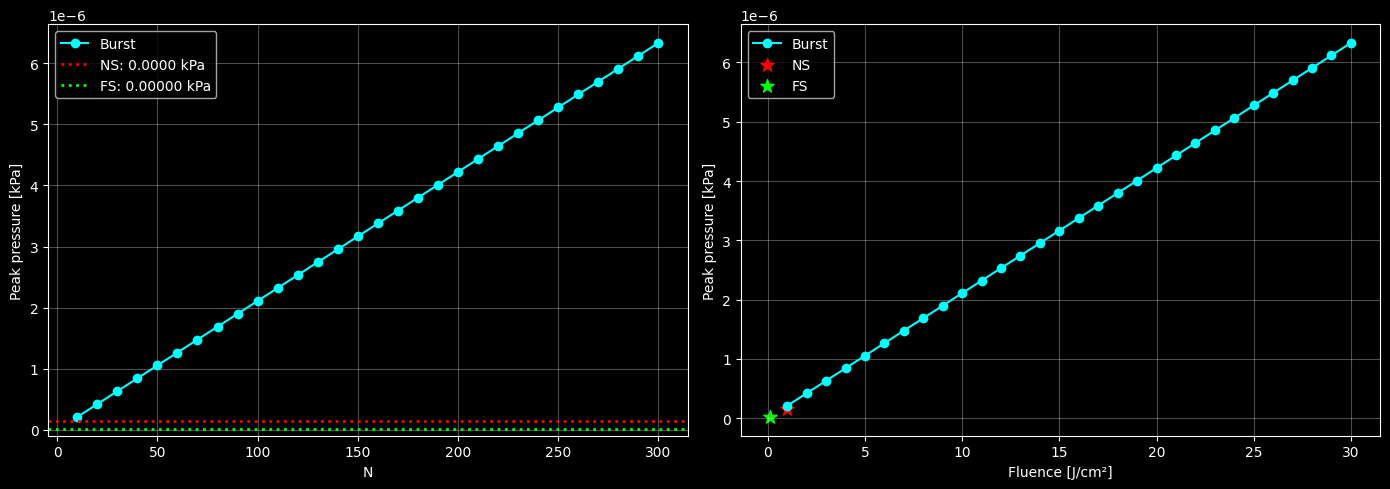

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

burst_df = df[df['label'].str.contains('burst')]
ns_p = df[df['label'] == 's01_ns_tau3ns_F1']['p_max_Pa'].values[0] * 1e-3
fs_p = df[df['label'] == 's02_fs_tau100fs_F01']['p_max_Pa'].values[0] * 1e-3

ax = axes[0]
ax.plot(burst_df['N'], burst_df['p_max_Pa'] * 1e-3, 'o-', color='cyan', label='Burst')
ax.axhline(ns_p, color='red', ls=':', lw=2, label=f'NS: {ns_p:.4f} kPa')
ax.axhline(fs_p, color='lime', ls=':', lw=2, label=f'FS: {fs_p:.5f} kPa')
ax.set_xlabel('N'); ax.set_ylabel('Peak pressure [kPa]')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(burst_df['F_Jcm2'], burst_df['p_max_Pa'] * 1e-3, 'o-', color='cyan', label='Burst')
ax.scatter([1.0], [ns_p], color='red', s=100, marker='*', label='NS')
ax.scatter([0.1], [fs_p], color='lime', s=100, marker='*', label='FS')
ax.set_xlabel('Fluence [J/cm²]'); ax.set_ylabel('Peak pressure [kPa]')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 4. Time traces

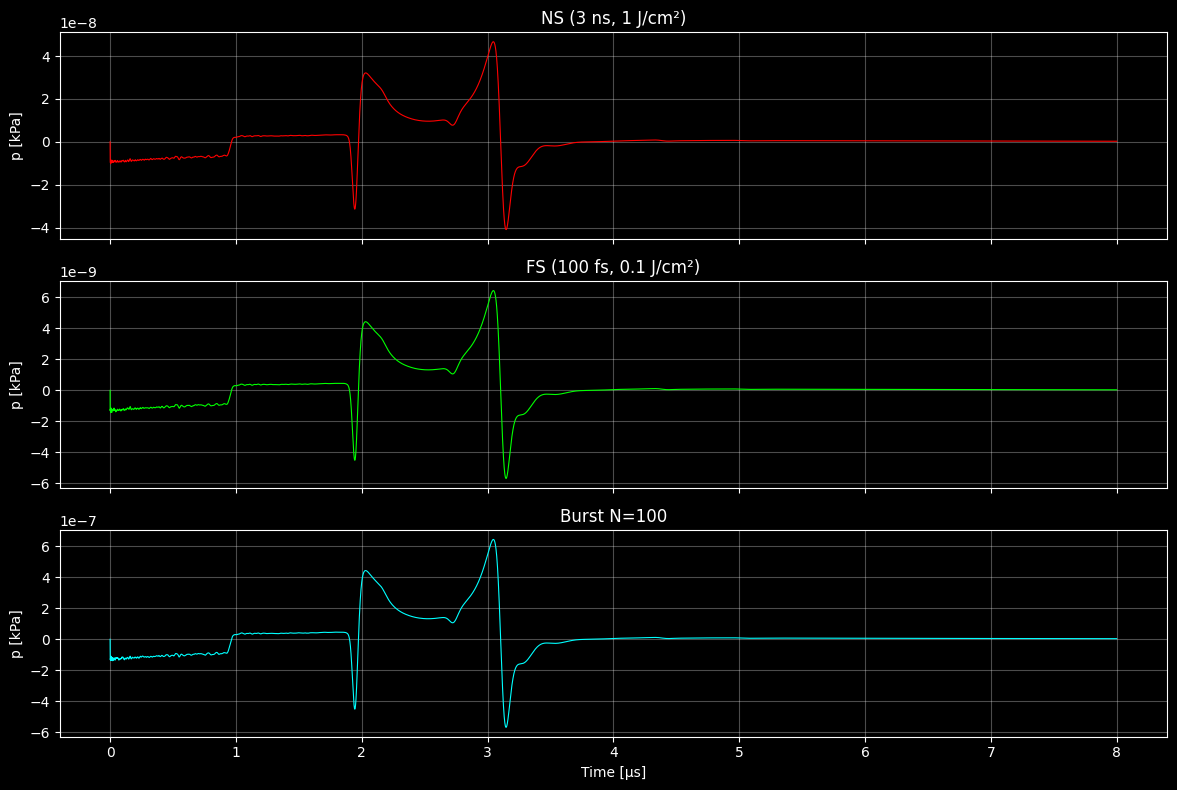

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for ax, (label, color, title) in zip(axes, [
    ('s01_ns_tau3ns_F1', 'red', 'NS (3 ns, 1 J/cm²)'),
    ('s02_fs_tau100fs_F01', 'lime', 'FS (100 fs, 0.1 J/cm²)'),
    ('s03_burst_N100', 'cyan', 'Burst N=100')
]):
    d = results[label]
    ax.plot(d['t_array'] * 1e6, d['sensor_data'][63, :] * 1e-3, color=color, lw=0.8)
    ax.set_ylabel('p [kPa]'); ax.set_title(title); ax.grid(alpha=0.3)

axes[-1].set_xlabel('Time [µs]')
plt.tight_layout(); plt.show()

## 5. p0 maps (focal region)

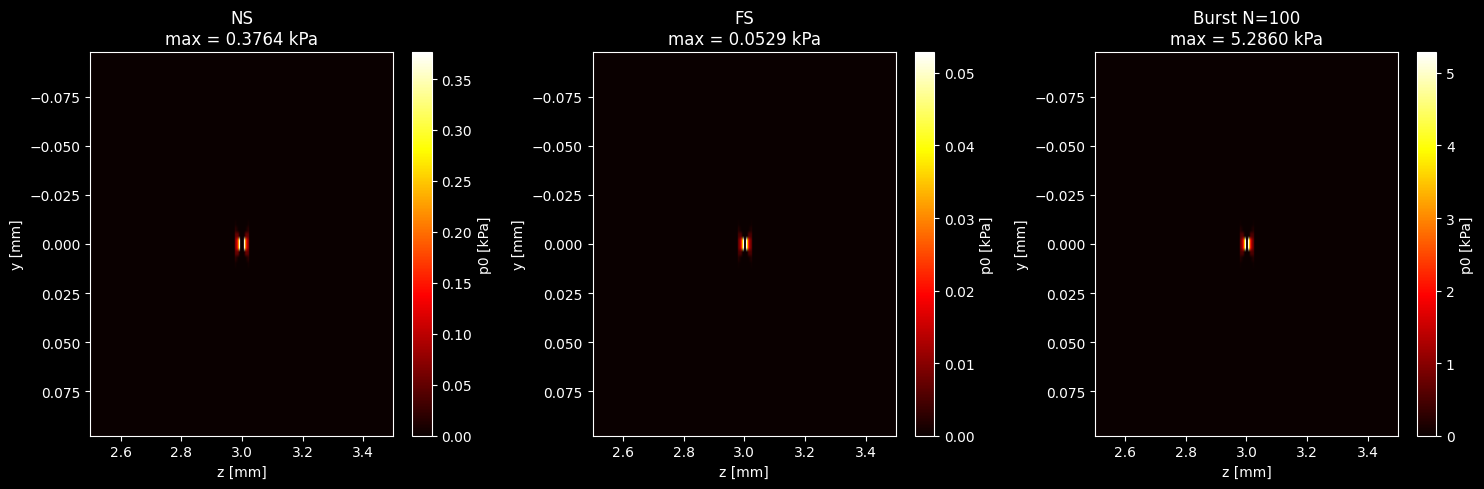

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (label, title) in zip(axes, [
    ('s01_ns_tau3ns_F1', 'NS'),
    ('s02_fs_tau100fs_F01', 'FS'),
    ('s03_burst_N100', 'Burst N=100')
]):
    d = results[label]
    p0 = d['p0_acoustic']  # shape (1000, 2000) = (Ny, Nz)
    y_mm = d['y_vec'] * 1e3
    z_mm = d['z_vec'] * 1e3
    z_focus = d['target_depth'] * 1e3
    
    # ROI indices
    yi = np.where((y_mm > -0.1) & (y_mm < 0.1))[0]
    zi = np.where((z_mm > z_focus - 0.5) & (z_mm < z_focus + 0.5))[0]
    
    p0_roi = p0[yi[0]:yi[-1]+1, zi[0]:zi[-1]+1]
    
    im = ax.imshow(p0_roi * 1e-3, extent=[z_mm[zi[0]], z_mm[zi[-1]], y_mm[yi[-1]], y_mm[yi[0]]],
                   aspect='auto', cmap='hot')
    ax.set_xlabel('z [mm]'); ax.set_ylabel('y [mm]')
    ax.set_title(f'{title}\nmax = {np.max(p0_roi)*1e-3:.4f} kPa')
    plt.colorbar(im, ax=ax, label='p0 [kPa]')

plt.tight_layout(); plt.show()

## 6. Linear scaling check

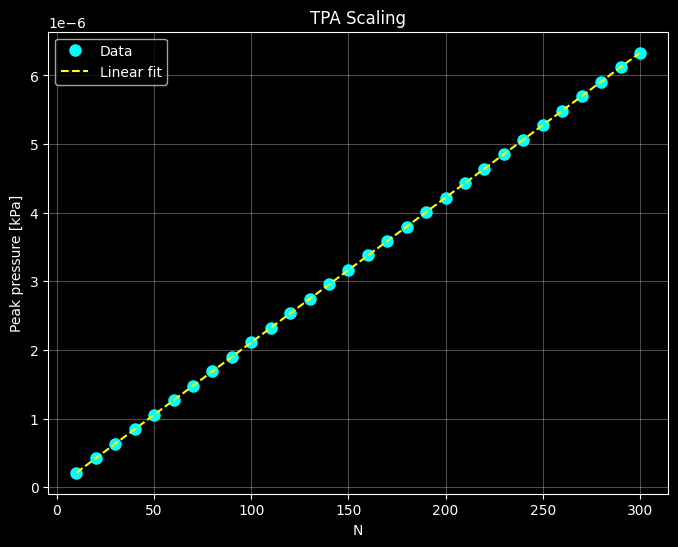

Slope: 0.0000 kPa/pulse


In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

N_vals = burst_df['N'].values
p_vals = burst_df['p_max_Pa'].values
coeffs = np.polyfit(N_vals, p_vals, 1)

ax.plot(N_vals, p_vals * 1e-3, 'o', color='cyan', ms=8, label='Data')
ax.plot(N_vals, np.polyval(coeffs, N_vals) * 1e-3, '--', color='yellow', label='Linear fit')
ax.set_xlabel('N'); ax.set_ylabel('Peak pressure [kPa]')
ax.set_title('TPA Scaling'); ax.legend(); ax.grid(alpha=0.3)
plt.show()

print(f"Slope: {coeffs[0]*1e-6:.4f} kPa/pulse")

## 7. B-mode

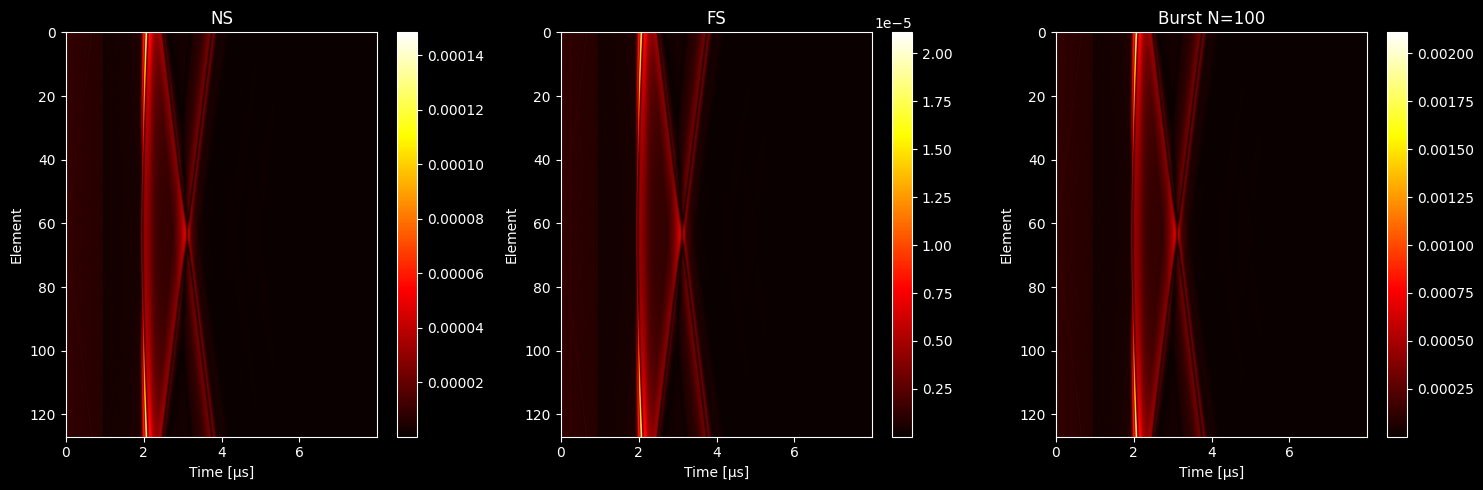

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (label, title) in zip(axes, [
    ('s01_ns_tau3ns_F1', 'NS'),
    ('s02_fs_tau100fs_F01', 'FS'),
    ('s03_burst_N100', 'Burst N=100')
]):
    d = results[label]
    t_us = d['t_array'] * 1e6
    im = ax.imshow(np.abs(d['sensor_data']), extent=[t_us[0], t_us[-1], 127, 0],
                   aspect='auto', cmap='hot')
    ax.set_xlabel('Time [µs]'); ax.set_ylabel('Element')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.tight_layout(); plt.show()

## 8. Summary

In [9]:
print("=== Peak Pressure ===")
print(f"NS:     {np.max(np.abs(results['s01_ns_tau3ns_F1']['sensor_data']))*1e-3:.4f} kPa")
print(f"FS:     {np.max(np.abs(results['s02_fs_tau100fs_F01']['sensor_data']))*1e-3:.5f} kPa")
print(f"Burst100: {np.max(np.abs(results['s03_burst_N100']['sensor_data']))*1e-3:.4f} kPa")
print()
print("=== Peak Intensity ===")
print(f"NS:  {1/3e-9:.2e} W/cm²")
print(f"FS:  {0.1/100e-15:.2e} W/cm²")
print(f"Ratio FS/NS: {(0.1/100e-15)/(1/3e-9):.0f}x")

=== Peak Pressure ===
NS:     0.0000 kPa
FS:     0.00000 kPa
Burst100: 0.0000 kPa

=== Peak Intensity ===
NS:  3.33e+08 W/cm²
FS:  1.00e+12 W/cm²
Ratio FS/NS: 3000x
